In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
from google.cloud import bigquery
import datetime

In [21]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines import CoxPHFitter

from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

# business day frequency calc
us_cal = USFederalHolidayCalendar()
us_bd = CustomBusinessDay(calendar=us_cal)

In [ ]:
people_query = """

with graduated_members as (
SELECT a. member_id FROM 
  (
    SELECT member_id FROM `dw.member_status` 
    WHERE stage_name in ('Out of Program', 'Independence')
    GROUP BY ALL
  ) a inner join (
    SELECT member_id FROM `dw.member_status` 
    WHERE stage_name in ( 'Support', 'In Program', 'Skill Building' )
    GROUP BY ALL
  ) b on a.member_id = b.member_id
  GROUP BY ALL
), 

member_start_dates as (
  select member_id, min(status_begin_date) start_date
  FROM `dw.member_status` right join graduated_members using(member_id)
  group by member_id
), 

analysis_set as (
  select member_id, start_date
  from member_start_dates
  where start_date between '2024-01-01' and '2025-12-31'
  GROUP BY ALL
)

SELECT member_id, stage_name, status_name, status_begin_time, status_end_time, client, is_graduated
FROM `dw.member_status` right join analysis_set using(member_id)
"""

bq_client = bigquery.Client(project='production-329012')
df = bq_client.query(people_query).to_dataframe()

/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


RefreshError: Reauthentication is needed. Please run `gcloud auth application-default login` to reauthenticate.

In [78]:
df.to_pickle('../data/member_data.pkl')

In [225]:
df = pd.read_pickle('../data/member_data.pkl')

In [226]:
df_people = df.copy()

df_people = df_people.assign(
    stage_name = df_people.stage_name.where(~df_people.stage_name.isin(['In Program', 'Support', 'Skill Building']), 'Active With Guide')
)

df_people.status_begin_time = pd.to_datetime(df_people.status_begin_time)
df_people = df_people.assign(
    reverse_state_order = df_people.groupby(['member_id', 'client']).status_begin_time.rank(method = 'dense', ascending = False)
)

terminal_states = df_people.loc[df_people.reverse_state_order == 1.]

# get rid of members who had status updates after Independence. Not useful in this analysis. 
terminal_states = terminal_states.loc[terminal_states.stage_name.isin(['Out of Program', 'Independence'])][['member_id', 'client', 'status_name']].rename(columns = {'status_name': 'terminal_state' })

df_people = df_people.merge(
    terminal_states, 
    on =[ 'member_id', 'client']
)

sankey = df_people.drop_duplicates(subset = ['member_id', 'stage_name', 'terminal_state'])


In [227]:
active_to_terminal = sankey.loc[sankey.stage_name == 'Active With Guide'][['member_id', 'stage_name', 'terminal_state']].drop_duplicates()
active_to_terminal = active_to_terminal.drop_duplicates(subset= ['member_id'])

outcome_data = active_to_terminal.groupby(['stage_name', 'terminal_state']).nunique().reset_index()



In [228]:
import plotly.express as px

fig = px.pie(outcome_data, values='member_id', names='terminal_state', title='Outcome Breakdown')
fig.show()


In [229]:
# remove outcomes that would bias the model because they are unpredictable

active_to_terminal = active_to_terminal.loc[~active_to_terminal.terminal_state.isin(['Off Plan', 'Deceased', 'Misconduct'])]
outcome_data_fixed = active_to_terminal.groupby(['stage_name', 'terminal_state']).nunique().reset_index()

fig = px.pie(outcome_data_fixed, values='member_id', names='terminal_state', title='Fixed Outcome Breakdown')
fig.show()

In [230]:
active_to_terminal.member_id.drop_duplicates()

1576     ae7955b0-314f-460f-8ad9-97b4f34ab878
1578     afd3e063-29b2-44f3-b041-42801b659360
1579     b3af8ca2-00b3-42f2-93f0-fd16ade16be1
1589     b4bf25d6-eca7-4104-9483-f39588bf6115
1592     3eeb1857-e8aa-4ef3-a1f8-304face85846
                         ...                 
37808    314494d5-1eec-4d20-b136-dbd835098280
39354    f1a1e3f4-73e5-4c70-b47a-6606c1b0c457
78649    ef1feeeb-3724-4004-b81c-a722b102c39e
78650    19b67525-8e64-4950-b307-71299e5132a1
78662    2eec68b4-67af-4a14-8ff4-96c112b32d32
Name: member_id, Length: 5151, dtype: object

In [231]:
sankey = df_people.merge(active_to_terminal[['member_id']], on = 'member_id', how = 'right')

client_data = sankey.groupby(['client']).member_id.nunique().reset_index()

fig = px.pie(client_data, values='member_id', names='client', title='Client Breakdown')
fig.show()

In [233]:
sankey = sankey.assign(
    state_order = sankey.groupby(['member_id', 'client', 'stage_name']).status_begin_time.rank(ascending= True, method = 'dense')
)

starts = sankey.loc[(sankey.stage_name == 'Active With Guide') & (sankey.state_order == 1.)].rename(
    columns = {'status_begin_time': 'tenure_start_date'}, 
)[['member_id', 'tenure_start_date']].drop_duplicates()

ends = sankey.loc[sankey.reverse_state_order == 1.].rename(
    columns = {'status_begin_time': 'tenure_end_date'}
)[['member_id', 'tenure_end_date', 'terminal_state', 'client']].drop_duplicates()

edge_list = starts.merge(ends, on = 'member_id')

# edge_list = edge_list.assign(
#     start_week= edge_list.tenure_start_date.dt.to_period('W').dt.start_time, 
#     end_week = edge_list.tenure_end_date.dt.to_period('W').dt.start_time, 
# )

edge_list = edge_list.assign ( 
    date= edge_list.apply(lambda row: pd.date_range(start=row.tenure_start_date, end = row.tenure_end_date, freq=us_bd, ), axis = 1)
)

In [234]:
client_counts = edge_list.groupby('client').member_id.nunique().sort_values()
edge_list = edge_list.merge(
    client_counts[client_counts >=  30].reset_index()[[ 'client']], on = 'client', how = 'right'
)

In [235]:
edge_list.client.unique()

array(['Medica Minnesota', 'UHC Florida', 'UHC Pennsylvania',
       'UHC Washington', 'UHC Virginia', 'UHC Michigan', 'OBH Wisconsin',
       'UHC Ohio', 'UHC New York', 'UHC New York: Statewide',
       'Medica Minnesota: Statewide', 'PEBA', 'Molina Nevada'],
      dtype=object)

In [236]:
edge_list['duration'] = edge_list.date.apply(len)

edge_list.client = edge_list.client.str.replace(
    ' ', '_'
).str.replace(
    ':',''
).str.lower()

edge_list = edge_list.assign(
    observed = 1
)

reference_client = 'peba'
df_model = pd.get_dummies(edge_list[['member_id', 'client', 'duration', 'observed']], columns=["client"], dtype=float)
df_model = df_model.drop(columns=[f'client_{reference_client}'])

client_cols = set(df_model.columns) - set(['member_id', 'duration', 'observed'])

formula = ' + '.join(client_cols)

In [237]:
results = multivariate_logrank_test(
    edge_list["duration"],
    edge_list["client"],
    edge_list["observed"],
)
print("── Log-Rank Test (are client curves significantly different?) ──")
print(f"  Test statistic : {results.test_statistic:.3f}")
print(f"  p-value        : {results.p_value:.4f}")
print(f"  Conclusion     : {'Curves differ significantly ✓' if results.p_value < 0.05 else 'No significant difference'}\n")

── Log-Rank Test (are client curves significantly different?) ──
  Test statistic : 1310.883
  p-value        : 0.0000
  Conclusion     : Curves differ significantly ✓



In [238]:

cox = CoxPHFitter()
cox.fit(
    df_model,
    duration_col  ="duration",
    event_col     ="observed",
    cluster_col   ="member_id",    # robust SEs — treats each member as a cluster
    formula       =formula,
)
 
print("── Cox Frailty Model Summary ──")
cox.print_summary(decimals=3)

── Cox Frailty Model Summary ──


<lifelines.CoxPHFitter: fitted with 5125 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'observed'
              cluster col = 'member_id'
          robust variance = True
      baseline estimation = breslow
   number of observations = 5125
number of events observed = 5125
   partial log-likelihood = -37995.454
         time fit was run = 2026-03-25 14:50:16 UTC

---
                                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                           
client_medica_minnesota           -1.114     0.328     0.106          -1.323          -0.905               0.266               0.404
client_uhc_virginia                0.885     2.422     0.065           0.757           1.013               2.131               2.754
client_uhc_new_york               -1.175     0.309     0.072          -1.316          -1.034               0.268               0.355
client_uhc_new_york_statewide     -0.407     0.666     0.049          -0.503          -0.311               0.605               0.733
client_uhc_florida                 0.424     1.528     0.061           0.305           0.542               1.357               1.720
client_uhc_michigan                0.629     1.875     0.056           0.519           0.739               1.680               2.093
client_uhc_washington              0.140     1.150     0.068           0.006           0.274               1.006               1.315
client_obh_wisconsin              -0.343     0.710     0.054          -0.449          -0.237               0.638               0.789
client_medica_minnesota_statewide  0.275     1.316     0.043           0.191           0.359               1.210               1.432
client_uhc_pennsylvania           -0.129     0.879     0.080          -0.287           0.028               0.750               1.029
client_molina_nevada               0.563     1.756     0.071           0.425           0.702               1.529               2.017
client_uhc_ohio                    0.298     1.347     0.051           0.198           0.397               1.219               1.488

                                   cmp to       z       p  -log2(p)
covariate                                                          
client_medica_minnesota             0.000 -10.466 <0.0005    82.733
client_uhc_virginia                 0.000  13.527 <0.0005   136.088
client_uhc_new_york                 0.000 -16.355 <0.0005   197.319
client_uhc_new_york_statewide       0.000  -8.289 <0.0005    52.956
client_uhc_florida                  0.000   6.999 <0.0005    38.496
client_uhc_michigan                 0.000  11.228 <0.0005    94.765
client_uhc_washington               0.000   2.044   0.041     4.611
client_obh_wisconsin                0.000  -6.331 <0.0005    31.939
client_medica_minnesota_statewide   0.000   6.384 <0.0005    32.433
client_uhc_pennsylvania             0.000  -1.609   0.108     3.216
client_molina_nevada                0.000   7.976 <0.0005    49.229
client_uhc_ohio                     0.000   5.857 <0.0005    27.663
---
Concordance = 0.638
Partial AIC = 76014.908
log-likelihood ratio test = 1323.801 on 12 df
-log2(p) of ll-ratio test = 914.964

In [248]:
# Create a representative "profile" row for each client
pred_profile = df_model[list(client_cols)].drop_duplicates().sort_values(list(client_cols), ascending=False)

pred_profile = pred_profile.assign(
    observed = 1, 
    duration = 1
).reset_index(drop=True)

index = [col for col in list(pred_profile.columns)+[f'client_{reference_client}', ] if col not in ['observed', 'duration']]
pred_profile.index = index

survival_curves = cox.predict_survival_function(pred_profile)

fig = px.line(survival_curves)
fig.show()

In [250]:
pred_profile.sum(axis = 1)

client_medica_minnesota              3.0
client_uhc_virginia                  3.0
client_uhc_new_york                  3.0
client_uhc_new_york_statewide        3.0
client_uhc_florida                   3.0
client_uhc_michigan                  3.0
client_uhc_washington                3.0
client_obh_wisconsin                 3.0
client_medica_minnesota_statewide    3.0
client_uhc_pennsylvania              3.0
client_molina_nevada                 3.0
client_uhc_ohio                      3.0
client_peba                          2.0
dtype: float64

In [261]:
def survival_at(curve_series, t):
    """Interpolate survival probability at time t from a survival curve Series."""
    idx = curve_series.index
    if t <= idx.min():
        return 1.0
    if t >= idx.max():
        return float(curve_series.iloc[-1])
    # Linear interpolation between surrounding time points
    lower = idx[idx <= t].max()
    upper = idx[idx >= t].min()
    s_lo  = curve_series[lower]
    s_hi  = curve_series[upper]
    if upper == lower:
        return float(s_lo)
    frac = (t - lower) / (upper - lower)
    return float(s_lo + frac * (s_hi - s_lo))


def churn_risk(client_id, current_tenure, horizon_months=3):
    """
    P(member churns in next `horizon_months` | survived to `current_tenure`).
    Falls back to client_A (reference/global) curve for unknown clients.
    """
    known_clients = survival_curves.columns.tolist()
    col = client_id if client_id in known_clients else "client_A"
    curve = survival_curves[col]

    s_now  = survival_at(curve, current_tenure)
    s_next = survival_at(curve, current_tenure + horizon_months)

    if s_now == 0:
        return 1.0
    return round(1 - s_next / s_now, 4)


churn_risk(client_id='client_uhc_ohio', current_tenure=1, horizon_months=200)

0.9736

In [ ]:
DARK_BG   = "#0f1117"
PANEL_BG  = "#1a1d27"
WHITE     = "#e8eaf0"
GREY      = "#8b8fa8"
COLORS    = ["#4f8ef7", "#3dd68c", "#f5a623", "#e05c5c", "#b57bee"]
CLIENT_LABELS = ["client_A", "client_B", "client_C", "client_D", "client_E"]

def style_ax(ax, title):
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2e3147")
    ax.tick_params(colors=GREY, labelsize=9)
    ax.xaxis.label.set_color(GREY)
    ax.yaxis.label.set_color(GREY)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight="bold", pad=10)
    ax.grid(color="#2e3147", linewidth=0.6, linestyle="--")

fig = plt.figure(figsize=(16, 14), facecolor=DARK_BG)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Panel 1: Survival curves per client (Cox model predictions) ──
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, "Survival Curves by Client  (shared frailty Cox model)")

for i, cid in enumerate(CLIENT_LABELS):
    curve = survival_curves[cid]
    n     = CLIENT_PROFILES[cid][0]
    ax1.plot(curve.index, curve.values,
             color=COLORS[i], linewidth=2.2,
             label=f"{cid}  (n={n})")

ax1.set_xlabel("Tenure (months)")
ax1.set_ylabel("P(still active)")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax1.legend(facecolor=PANEL_BG, edgecolor="#2e3147", labelcolor=WHITE, fontsize=9)

# ── Panel 2: KM curves per client (raw, unstratified) for comparison ──
ax2 = fig.add_subplot(gs[1, 0])
style_ax(ax2, "Raw KM Curves by Client  (no shrinkage, for comparison)")

for i, cid in enumerate(CLIENT_LABELS):
    kmf = KaplanMeierFitter()
    sub = df[df["client_id"] == cid]
    kmf.fit(sub["duration_months"], sub["observed"], label=cid)
    kmf.plot_survival_function(ax=ax2, color=COLORS[i], linewidth=1.8, ci_show=False)

ax2.set_xlabel("Tenure (months)")
ax2.set_ylabel("P(still active)")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.get_legend().remove()

# ── Panel 3: 24-month headcount forecast per client ──
ax3 = fig.add_subplot(gs[1, 1])
style_ax(ax3, "24-Month Headcount Forecast per Client  (20 new/month)")

for i, cid in enumerate(CLIENT_LABELS):
    fc = forecast_all[forecast_all["client_id"] == cid]
    ax3.plot(fc["month"], fc["active_members"],
             color=COLORS[i], linewidth=2, label=cid)

ax3.set_xlabel("Month from now")
ax3.set_ylabel("Active members")
ax3.legend(facecolor=PANEL_BG, edgecolor="#2e3147", labelcolor=WHITE, fontsize=9)

fig.suptitle("Member Attrition Model  ·  Shared Frailty (Mixed-Effects Survival)",
             color=WHITE, fontsize=14, fontweight="bold", y=0.98)

plt.savefig("frailty_model.png", dpi=160, bbox_inches="tight", facecolor=DARK_BG)
print("\nChart saved to frailty_model.png")

In [243]:
data = edge_list.explode('date')

# if tenure is less than 1 week, date is nan, so fill it in with start date
data = data.assign(
    date = data.date.where(~data.date.isna(), data.tenure_start_date)
)

data = data.assign(
    week_no = data.groupby(['member_id', 'client']).date.rank(ascending = True, method = 'dense'), 
    end_date = data.groupby(['member_id', 'client']).date.rank(ascending = False, method = 'dense')

)

data = data.assign(
    end_date = data.end_date.where(data.end_date == 1., 0)
)


<Axes: xlabel='week_no', ylabel='member_id'>

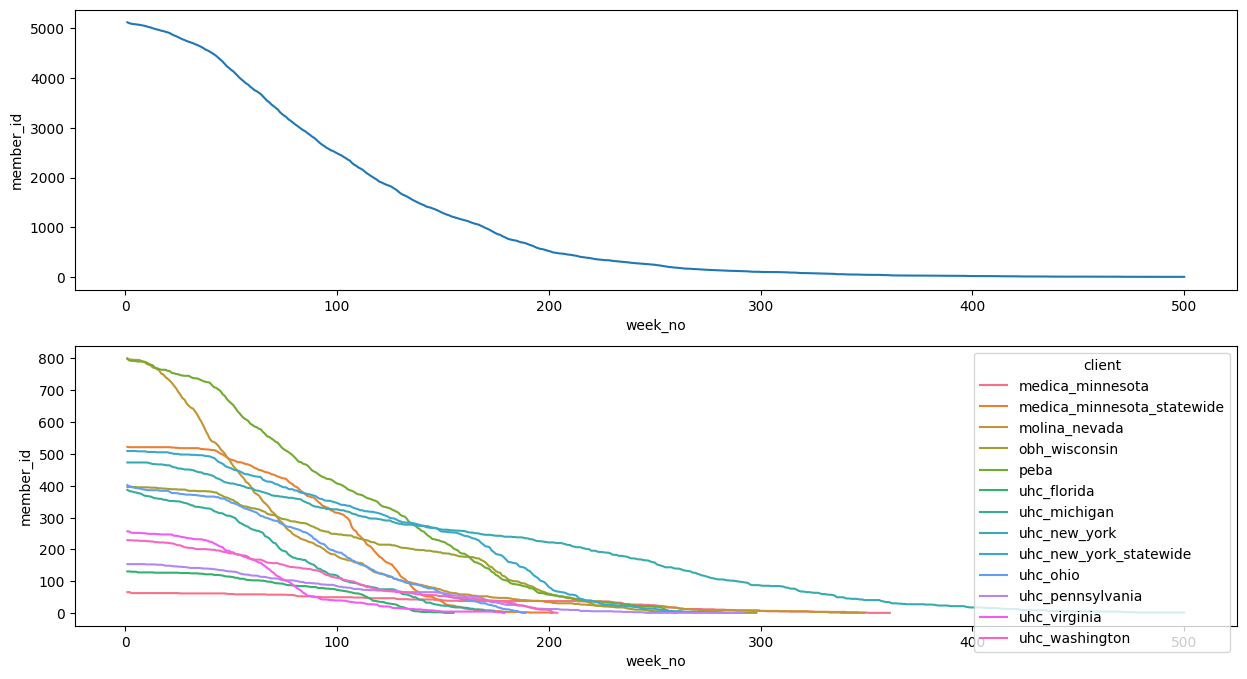

In [244]:

fig, ax= plt.subplots(figsize = (15, 8), nrows=2)
sns.lineplot(data.groupby(['week_no']).member_id.nunique(), ax = ax[0])
sns.lineplot(data.groupby(['week_no', 'client']).member_id.nunique().reset_index(), x = 'week_no', y= 'member_id', ax = ax[1], hue='client')

<Axes: xlabel='week_no', ylabel='survival_func'>

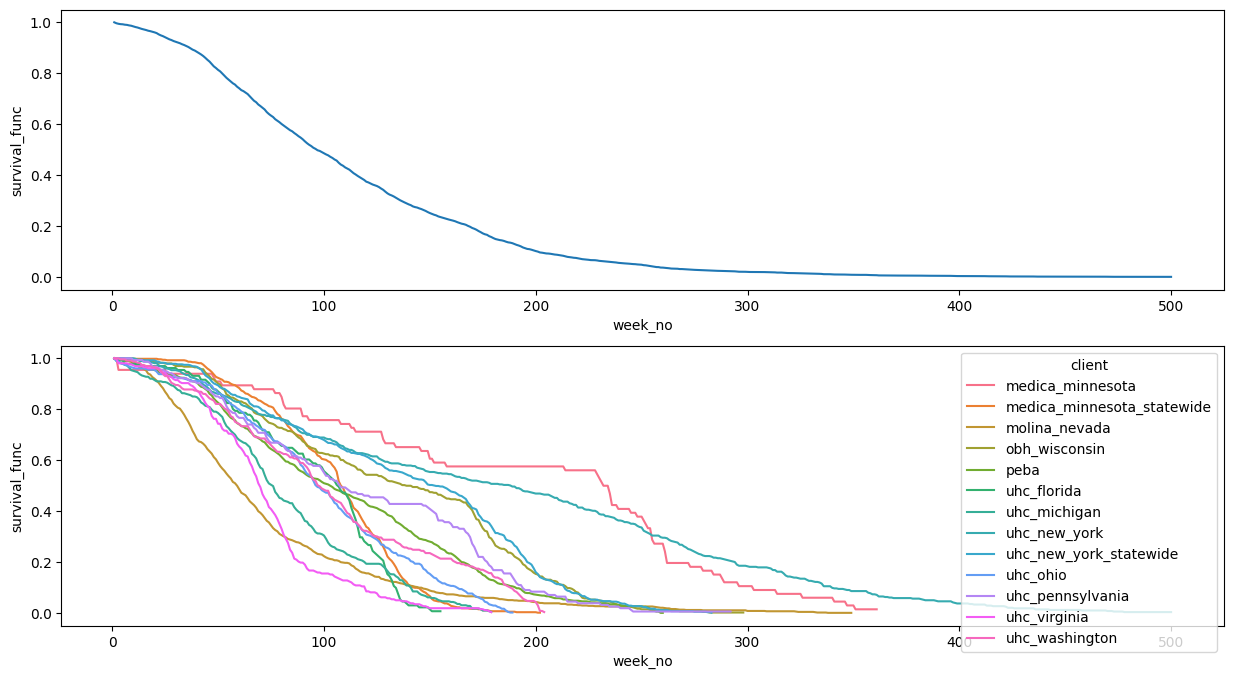

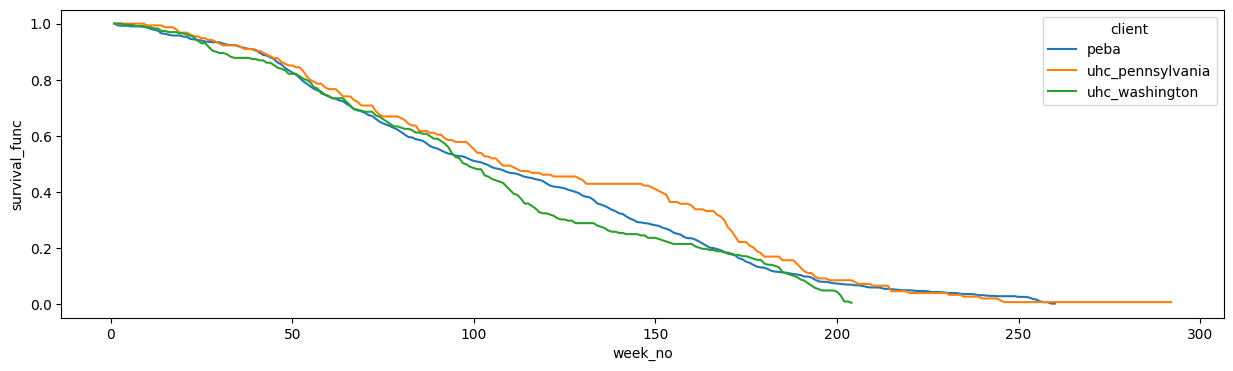

In [247]:
survival = data.groupby(['week_no']).agg(
    n_members = ('member_id', 'nunique')
).assign(
    total_members = data.member_id.nunique()
)

survival = survival.assign(
    survival_func = survival.n_members / survival.total_members
)

client_survival = data.groupby(['client', 'week_no']).agg(
    n_members = ('member_id', 'nunique'), 
).reset_index()

client_survival = client_survival.merge(
    data.groupby('client').member_id.nunique().reset_index().rename(columns = {'member_id':'total_members'}), on = 'client'
)

client_survival = client_survival.assign(
    survival_func = client_survival.n_members / client_survival.total_members
)

fig, ax= plt.subplots(figsize = (15, 8), nrows=2)
sns.lineplot(survival, x = 'week_no', y = 'survival_func', ax = ax[0])
sns.lineplot(client_survival, x = 'week_no', y = 'survival_func', ax = ax[1], hue = 'client')


fig, ax= plt.subplots(figsize = (15, 4))
sns.lineplot(client_survival.loc[client_survival.client.isin(['uhc_washington', 'peba', 'uhc_pennsylvania'])], x = 'week_no', y= 'survival_func', ax = ax, hue='client')



In [ ]:
ts_query = """
    SELECT  file_client_id, file_dt, count(distinct member_id) FROM 
    (SELECT member_id, file_client_id, file_dt, table_name, 
    ROW_NUMBER() OVER(partition by member_id, file_client_id order by file_dt asc) enter_field
    FROM `production-329012.dw_staging.eligibility_canon_member`) a
    WHERE a. enter_field = 1
    GROUP BY file_client_id, file_dt
    ORDER BY file_client_id, file_dt
"""
bq_client = bigquery.Client(project='production-329012')
ts = bq_client.query(ts_query).to_dataframe()


/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/abe.phillips/Documents/staffing-headcount/.staffing/lib/python3.14/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<Axes: xlabel='file_dt', ylabel='f0_'>

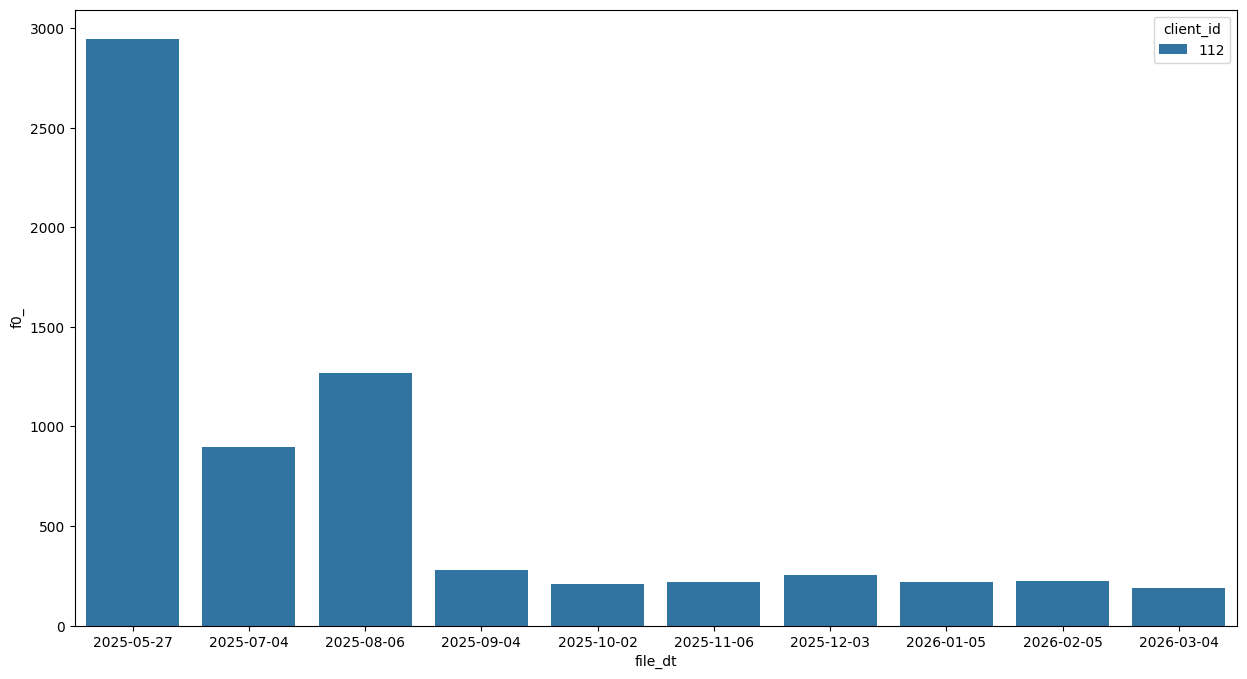

In [53]:
ts = ts.assign(
    client_id = ts.file_client_id.astype(str)
)

fig, ax = plt.subplots(figsize = (15, 8))
sns.barplot(ts.loc[ts.client_id == '112'], x = 'file_dt', y = 'f0_', hue = 'client_id')

In [44]:
ts

,file_client_id,file_dt,f0_
0,<NA>,2023-03-29,0
1,1,2021-01-15,0
2,2,2022-09-22,1000
3,2,2022-11-04,3267
4,2,2023-01-24,2018
...,...,...,...
214,114,2026-03-03,290
215,115,2025-12-03,3017
216,115,2026-01-05,369
217,115,2026-02-04,304
